# From archival pages to auditable personnel links

The wider research studies how administrative personnel persist or change through political transitions, and how that continuity relates to later economic outcomes. This example demonstrates the data construction needed to investigate that question: converting archival pages into structured records and auditable links between people.

This standalone demonstration explains two deliberately selected cases using four real, redacted excerpts. Names are retained; the city, exact years and source identifiers are concealed. It illustrates data construction, not a population continuity estimate or an economic effect. Prepared with AI coding assistance for Urs Maier.

**Reading route:** inspect the source and OCR → understand the comparison fields → inspect all excerpt-level candidates → work through one score and both directions of competition → compare decisions with previously recorded reviews.

## 1. Know the input and its scope

An **entry** is one printed occurrence, not necessarily a distinct person; an **anchor** is an earlier entry chosen for explanation. These are excerpts, not complete municipal rosters. The two anchors were deliberately selected to contrast a compatible abbreviated identity and a conflicting same-surname candidate. Selection is informed by prior judgements, so this is not independent performance validation.

The first cell checks and replays saved OCR. It does not make a new API call or load review outcomes.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from ocr import ROOT, read_page, PROMPT
from linkage import (extract, select_anchors, candidate_pairs, find_matches,
                     normalise, career_text, sim, score_components,
                     WEIGHTS, SURNAME_FLOOR, MATCH_THRESHOLD, MIN_MARGIN, MIN_CONFIDENCE)
from run import read_csv, run
from visualise import pages, comparison, export
%matplotlib inline
pd.set_option('display.max_colwidth', None)
records, page_audit = extract()
records_df = pd.DataFrame(records)
manifest = json.loads((ROOT/'data/manifest.json').read_text())
display(pd.DataFrame(page_audit)[['page_id', 'people', 'confidence']].rename(
    columns={'page_id': 'Excerpt', 'people': 'Extracted entries', 'confidence': 'Self-rated OCR confidence'}))
print(f"Total: {len(records)} entries; "
      f"{sum(r['period']=='earlier' for r in records)} earlier; "
      f"{sum(r['period']=='later' for r in records)} later.")

,Excerpt,Extracted entries,Self-rated OCR confidence
0,sample-a-before,25,0.98
1,sample-a-after,46,0.98
2,sample-b-before,52,0.95
3,sample-b-after,14,0.95


Total: 137 entries; 77 earlier; 60 later.


## 2. Inspect the printed evidence beside the OCR

Read each figure from the original printing to the typed fields. The small pages locate the enlarged regions; blue rectangles are manually reviewed display windows, not OCR detections. Raw names and entries remain separate from derived comparison fields.

**Case A:** the earlier **Huber August** is a Stadtamtmann in the youth-welfare office. The later **Aug. Huber** has a compatible abbreviated name, related office and the same rank abbreviation. Notice that the OCR places the rank in **role** earlier and **title** later. Comparing across fields recovers that evidence without rewriting either extraction.

[Full earlier excerpt](data/pages/sample-a-before.png) · [Full later excerpt](data/pages/sample-a-after.png)

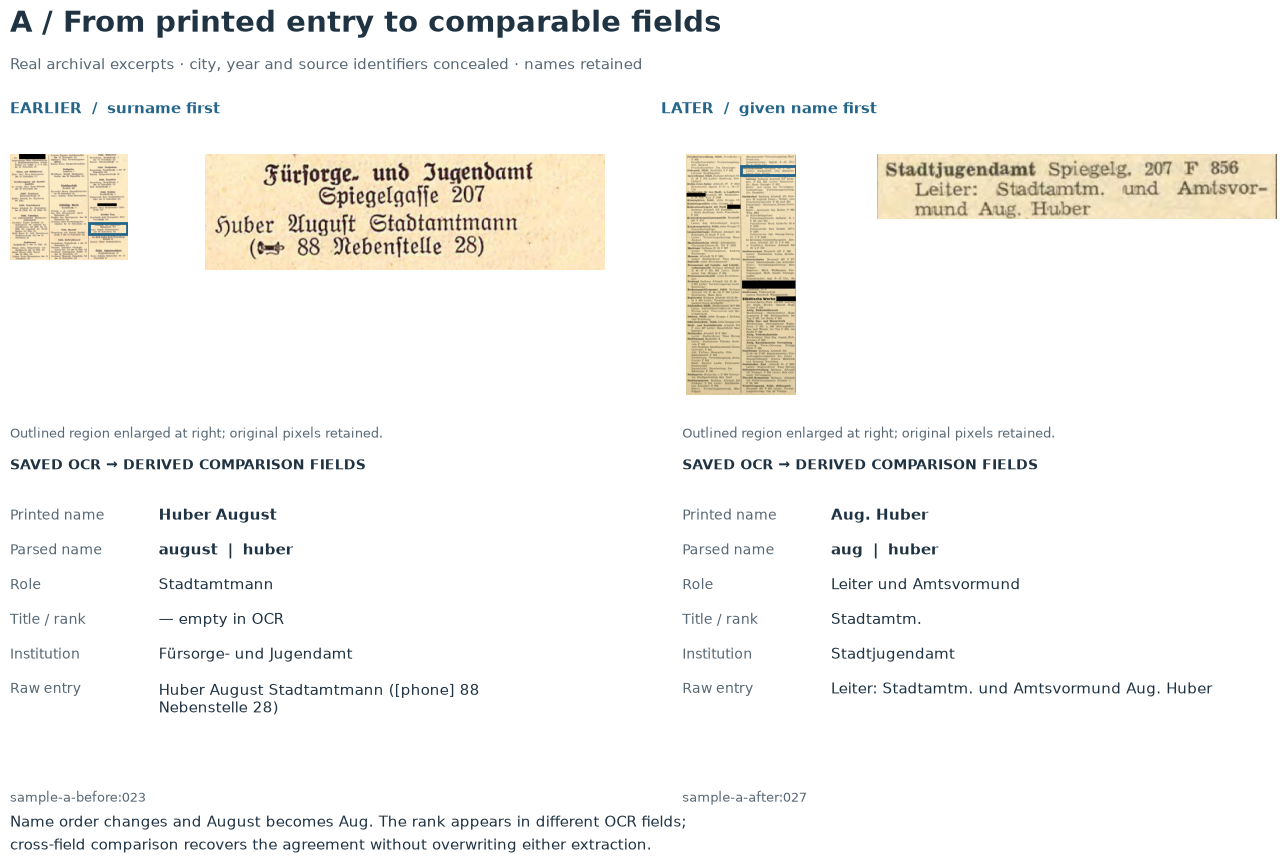

In [2]:
fig = pages('a', records)
export(fig, 'source_a')
display(fig)
plt.close(fig)

**Case B:** the earlier **Eder Rupert** is a gendarmerie officer; the later **Roman Eder** holds a different administrative position. The surname agrees, but the given names and careers differ. This figure allows inspection of one proposed pair; it cannot establish that Rupert is absent from a complete later roster.

[Full earlier excerpt](data/pages/sample-b-before.png) · [Full later excerpt](data/pages/sample-b-after.png)

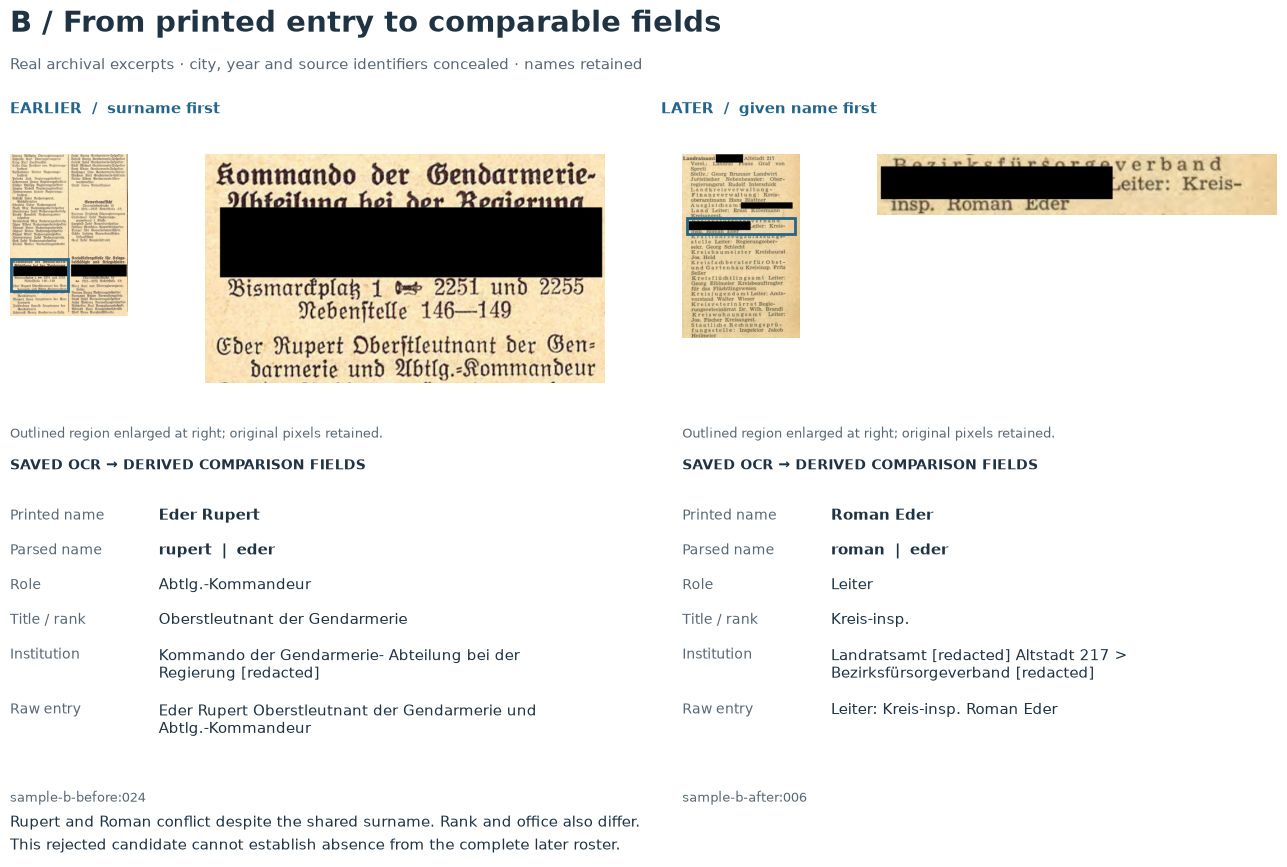

In [3]:
fig = pages('b', records)
export(fig, 'source_b')
display(fig)
plt.close(fig)

## 3. See what the OCR receives and returns

Each live call receives one redacted image, this extraction prompt and a JSON schema for transcription, confidence, entries and heading context. It does not receive the other period, matching labels or concealed source material. The actual saved response excerpt below contains the printed name, role, title, address, hierarchy and raw entry.

The offline path verifies image/prompt/schema/configuration hashes. `python ocr.py --live` explicitly requests a new, charged run. Self-rated page confidence is not measured OCR accuracy; a hidden or missing heading must remain unknown. Full saved transcriptions remain in `data/ocr/`; only the focal response entry is printed here.

In [4]:
print(PROMPT)
saved = read_page(manifest[0])
print('Model:', saved['model'])
print('Image SHA-256:', saved['image_sha256'])
entry = next(e for e in saved['page']['entries'] if e['name'] == 'Huber August')
print(json.dumps(entry, ensure_ascii=False, indent=2))

Read this redacted historical German address-book excerpt visually. Return a full plain-text
transcription in reading order, and extract every explicitly named person in an
institutional section. Preserve the printed name, role (function), title (rank or
honorific), address and heading hierarchy separately. Do not expand initials, fix
names, infer identity, or invent missing text. Names after a comma remain as printed.
Addresses, office hours, telephone numbers and unnamed positions are not people.
institution_path lists visible headings from broadest to most specific. Do not add
the page banner to the hierarchy. For entries continuing from the previous page
without a visible institution, set continued=true and institution_path=[]. Do not
invent the previous heading. Record active_hierarchy_at_end for the last section.
Black rectangles conceal identifying source details. Transcribe them as [redacted]
and never infer the city, year, source, or hidden words. A crop may begin mid-section;

## 4. Derive comparable fields without inventing names

Page conventions are visually checked: earlier entries use surname first, later entries given name first; an explicit comma overrides that convention. Lowercase text, ae/oe/ue for umlauts and ss for ß, and removal of punctuation produce comparison strings. **Aug. stays aug**, not an invented expansion. Unrelated mixed-order or compound names are not all manually validated.

The given-name rule scores an exact match as 1, a compatible multi-letter prefix as 0.8, a single initial as 0.5, and missing or conflicting names as 0. Initial-only or missing evidence remains under review.

In [5]:
anchors = select_anchors(records, read_csv(ROOT/'data/anchors.csv'))
display(records_df.loc[records_df['name'].isin(
    ['Huber August', 'Aug. Huber', 'Eder Rupert', 'Roman Eder']),
    ['name', 'given', 'surname']].rename(columns={
        'name': 'Printed name', 'given': 'Derived given name', 'surname': 'Derived surname'}))

,Printed name,Derived given name,Derived surname
22,Huber August,august,huber
51,Aug. Huber,aug,huber
94,Eder Rupert,rupert,eder
128,Roman Eder,roman,eder


## 5. Generate the full excerpt-level comparison pool

Compare every earlier entry with every later entry in the same neutral town. Surname similarity must reach the blocking threshold. The two anchors only select which decisions to explain; they do not restrict who can compete for a later entry. Blank case IDs in the exported pool denote supporting entries.

Surname, rank/role and office similarities use `difflib.SequenceMatcher`: twice the characters in matching blocks divided by the combined string lengths, after normalisation. Empty fields score zero. This is textual resemblance, not a semantic or identity probability. All blocked pairs remain in competition, including given-name conflicts.

In [6]:
anchor_cases = {a['record_id']: a['case_id'] for a in anchors}
earlier = [dict(r, case_id=anchor_cases.get(r['record_id'], ''))
           for r in records if r['period'] == 'earlier']
pool = candidate_pairs(earlier, records)
focal_pairs = [p for p in pool if p['left_id'] in anchor_cases]
print(f"Surname filter: {SURNAME_FLOOR:.2f}; {len(pool)} blocked pairs; "
      f"{len(focal_pairs)} focal pairs; {len(anchors)} focal anchors.")
display(pd.DataFrame(focal_pairs)[['left_name', 'right_name', 'given_relation']].rename(
    columns={'left_name': 'Earlier entry', 'right_name': 'Later candidate', 'given_relation': 'Given-name evidence'}))

Surname filter: 0.82; 15 blocked pairs; 3 focal pairs; 2 focal anchors.


,Earlier entry,Later candidate,Given-name evidence
0,Huber August,Aug. Huber,abbreviation
1,Huber August,Simon Huber,conflict
2,Eder Rupert,Roman Eder,conflict


## 6. Work through August Huber's score

Normalise an explicit short list of rank abbreviations, including Stadtamtm. → stadtamtmann. Compare all four earlier/later role/title combinations and retain the highest ratio. The table below shows those actual comparison strings. Compare the normalised full institutional paths separately; use only the **stronger** of rank/role and office similarities in the final score.

The weighted contributions below call the same scoring function as the pipeline. Weights and thresholds are illustrative teaching choices, not fitted or calibrated estimates.

In [7]:
proposal = next(p for p in focal_pairs if p['case_id'] == 'A' and p['right_name'] == 'Aug. Huber')
by_id = {r['record_id']: r for r in records}
left, right = by_id[proposal['left_id']], by_id[proposal['right_id']]
career_rows = [dict(Earlier_field=a, Earlier_text=career_text(left[a]) or '(empty)',
                    Later_field=b, Later_text=career_text(right[b]) or '(empty)',
                    Similarity=sim(career_text(left[a]), career_text(right[b])))
               for a in ('role', 'title') for b in ('role', 'title')]
display(pd.DataFrame(career_rows).round(3))
assert max(row['Similarity'] for row in career_rows) == proposal['career_similarity']
print('Office comparison strings:')
print(normalise(left['institution']))
print(normalise(right['institution']))
print(f"Office ratio: {sim(left['institution'], right['institution']):.6f}")
components = score_components(proposal)
values = [proposal['surname_similarity'], proposal['given_agreement'],
          max(proposal['career_similarity'], proposal['institution_similarity'])]
display(pd.DataFrame({'Evidence': ['Surname', 'Given name', 'Stronger context'],
                      'Similarity': values, 'Weight': list(WEIGHTS.values()),
                      'Contribution': list(components.values())}).round(3))
print('Score:', ' + '.join(f'{v:.3f}' for v in components.values()), '=', f"{proposal['score']:.3f}")
print(f"Minimum confidence across this pair's pages: {proposal['ocr_min']:.2f}; required: {MIN_CONFIDENCE:.2f}")
display(Markdown('**Component audit:** the three focal pairs plus Huber’s reverse competitor. '
                 'Values below come from the complete comparison pool; the score uses the stronger rank/role or office value. '
                 'Six decimals permit closer reconstruction than the rounded chart labels.'))
audit_pairs = [p for p in pool if p['left_id'] in anchor_cases or p['right_id'] == proposal['right_id']]
display(pd.DataFrame(audit_pairs)[['left_name', 'right_name', 'surname_similarity',
    'given_agreement', 'career_similarity', 'institution_similarity', 'score']].rename(columns={
    'left_name': 'Earlier', 'right_name': 'Later', 'surname_similarity': 'Surname',
    'given_agreement': 'Given', 'career_similarity': 'Rank/role',
    'institution_similarity': 'Office', 'score': 'Score'}).round(6))

,Earlier_field,Earlier_text,Later_field,Later_text,Similarity
0,role,stadtamtmann,role,leiter und amtsvormund,0.412
1,role,stadtamtmann,title,stadtamtmann,1.000
2,title,(empty),role,leiter und amtsvormund,0.000
3,title,(empty),title,stadtamtmann,0.000


Office comparison strings:
fuersorge und jugendamt
stadtjugendamt
Office ratio: 0.594595


,Evidence,Similarity,Weight,Contribution
0,Surname,1.0,0.55,0.55
1,Given name,0.8,0.25,0.20
2,Stronger context,1.0,0.20,0.20


Score: 0.550 + 0.200 + 0.200 = 0.950
Minimum confidence across this pair's pages: 0.98; required: 0.80


**Component audit:** the three focal pairs plus Huber’s reverse competitor. Values below come from the complete comparison pool; the score uses the stronger rank/role or office value. Six decimals permit closer reconstruction than the rounded chart labels.

,Earlier,Later,Surname,Given,Rank/role,Office,Score
0,Huber Ludwig,Aug. Huber,1.0,0.0,0.347826,0.428571,0.635714
1,Huber August,Aug. Huber,1.0,0.8,1.000000,0.594595,0.950000
2,Huber August,Simon Huber,1.0,0.0,0.400000,0.057143,0.630000
3,Eder Rupert,Roman Eder,1.0,0.0,0.272727,0.260163,0.604545


## 7. Check competition in both directions, then decide

**Forward:** which later candidate has the highest score for this earlier entry? **Reverse:** does that later candidate prefer this earlier entry over every other blocked earlier entry? A margin is the proposed pair's score minus its strongest alternative's score. Reverse margins can be negative when another earlier entry wins.

If no alternative exists, the margin is undefined: display **“No competing candidate”** and leave it blank in CSV. Do not compare with an imaginary zero-scoring entry. The score, name and source-confidence safeguards still apply. Ties stay under review, even if the required margin is zero. Given-name conflicts remain in the competitor pool, but a conflicting proposed pair cannot be accepted.

In [8]:
decisions = find_matches(anchors, pool)
display(Markdown(f"Acceptance requires score ≥ **{MATCH_THRESHOLD:.2f}**, a strict best choice in both directions, "
                 f"margins ≥ **{MIN_MARGIN:.2f}** wherever alternatives exist, compatible name evidence "
                 f"and self-rated page confidence ≥ **{MIN_CONFIDENCE:.2f}**."))
display(pd.DataFrame(decisions)[['case_id', 'name', 'best_candidate', 'score', 'status']].round(3))
for d in decisions:
    for direction, count_key, id_key, score_key, gap_key in [
        ('Forward', 'candidate_count', 'runner_up_id', 'runner_up_score', 'margin'),
        ('Reverse', 'reverse_candidate_count', 'reverse_runner_up_id', 'reverse_runner_up_score', 'reverse_margin')]:
        other = by_id[d[id_key]]['name'] if d[id_key] else 'No competing candidate'
        detail = (f"; {d['score']:.3f} − {d[score_key]:.3f} = {d[gap_key]:.3f}"
                  if d[gap_key] is not None else '; margin not defined')
        print(f"{d['case_id']} {direction}: {d[count_key]} candidate(s), including the proposal; alternative: {other}{detail}")
    print('Decision reason:', d['reason'])

Acceptance requires score ≥ **0.84**, a strict best choice in both directions, margins ≥ **0.08** wherever alternatives exist, compatible name evidence and self-rated page confidence ≥ **0.80**.

,case_id,name,best_candidate,score,status
0,A,Huber August,Aug. Huber,0.950,accepted
1,B,Eder Rupert,Roman Eder,0.605,no_link


A Forward: 2 candidate(s), including the proposal; alternative: Simon Huber; 0.950 − 0.630 = 0.320
A Reverse: 2 candidate(s), including the proposal; alternative: Huber Ludwig; 0.950 − 0.636 = 0.314
Decision reason: accepted
B Forward: 1 candidate(s), including the proposal; alternative: No competing candidate; margin not defined
B Reverse: 1 candidate(s), including the proposal; alternative: No competing candidate; margin not defined
Decision reason: given_name_conflict


### Read the evidence and the competition together

The upper matrix shows four similarities on a common 0–1 scale; the bars decompose their weighted score. Darker cells mean greater textual agreement, not greater certainty about identity. The dashed line shows the actual acceptance floor.

The lower panels make the two directions explicit. **Simon Huber** competes in the forward direction; the previously unselected **Huber Ludwig** competes in the reverse direction. Both count even though their given names conflict. These comparisons cover all entries in the provided excerpts, not complete historical rosters.

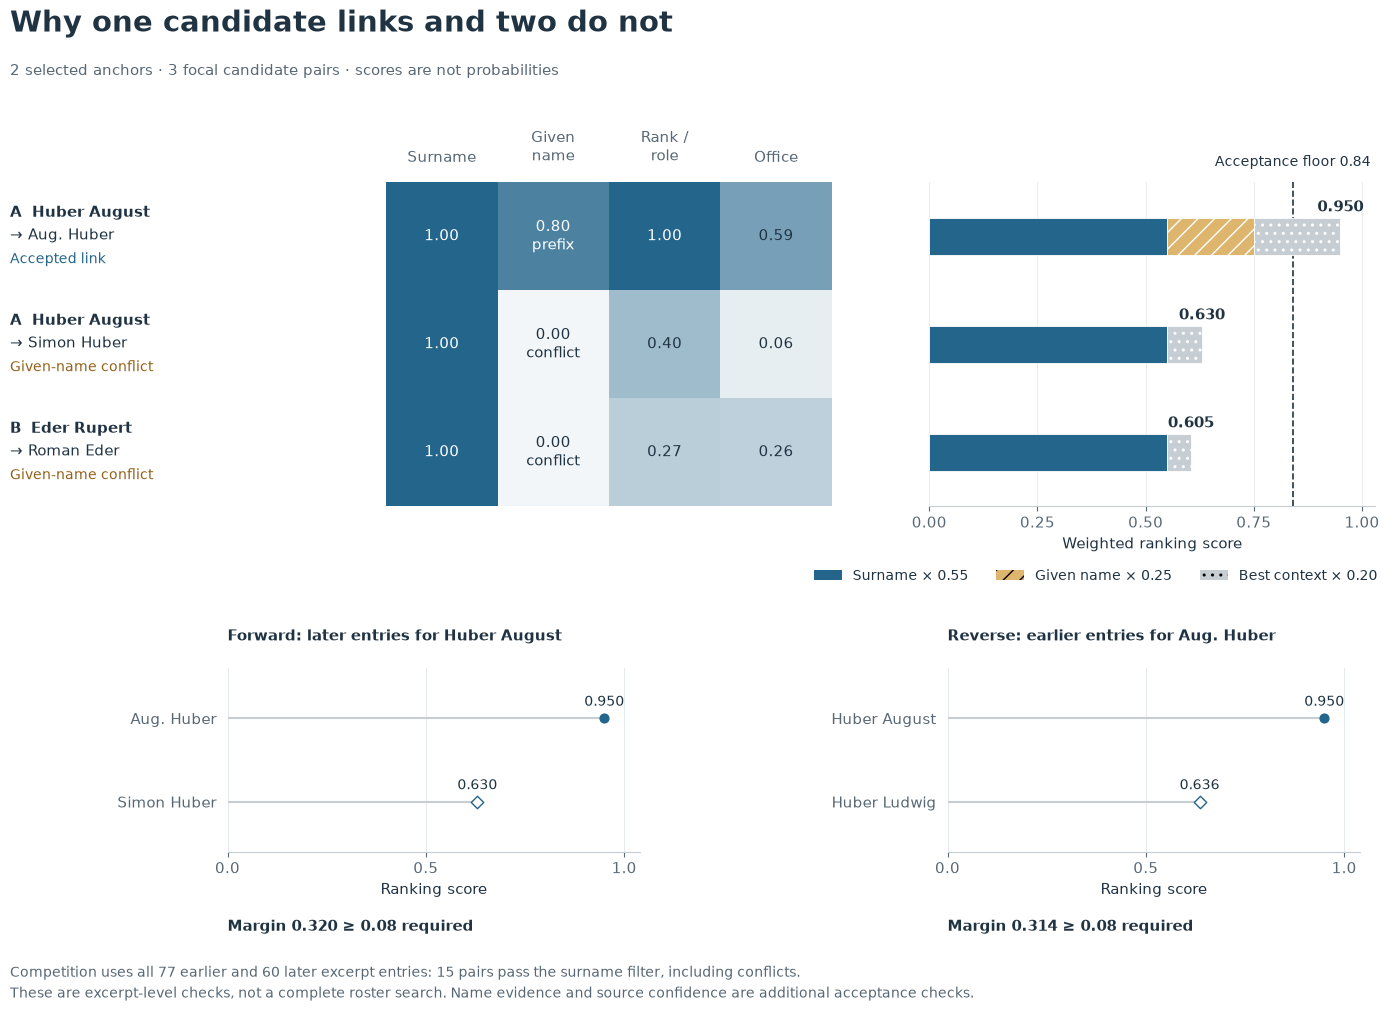

In [9]:
fig = comparison(focal_pairs, decisions, pool, records)
export(fig, 'evidence')
display(fig)
plt.close(fig)

## 8. Compare with the previously recorded judgements

Only now load the saved review labels. The examples were deliberately selected using prior judgements; loading labels after scoring prevents their direct use by this rule but does not make the exercise blind or independent validation.

**Provenance limits:** the sample does not document the original reviewer's identity, review date or additional corroboration. The full saved explanations appear below. Visible name/rank/office evidence can be inspected in the figures. The earlier full-roster search is reported by the saved note, not reproduced here. A rejected candidate or missing observed link does not establish departure, death, or a particular consequence of political transition.

In [10]:
reviews = read_csv(ROOT/'data/reviewed_pairs.csv')
for review in reviews:
    decision = next(d for d in decisions if d['case_id'] == review['case_id'])
    display(Markdown(f"**Case {review['case_id']} — recorded judgement: {review['reviewed_decision']}.**\n\n"
                     f"Saved review explanation: {review['evidence']}\n\n"
                     f"Pipeline result: **{decision['status']}** ({decision['reason']})."))

**Case A — recorded judgement: same_person.**

Saved review explanation: Compatible abbreviated given name; same surname and municipal youth-welfare context; rank agrees.

Pipeline result: **accepted** (accepted).

**Case B — recorded judgement: different_person.**

Saved review explanation: Same surname but conflicting given names and different administrative careers; no match found in the original roster review.

Pipeline result: **no_link** (given_name_conflict).

## 9. Understand the conflict guard and the limits

With a given-name conflict, its contribution is zero. Even perfect surname and context similarities cannot lift the score above the sum of those two weights. Removing the conflict guard alone therefore cannot change the displayed decisions at the default threshold. The guard supplies an explicit rejection reason and remains protective if a lower threshold is tried.

**Exercise:** calculate that maximum and explain the result of the lower-threshold check below. Then explain why a single initial or missing name still requires review even when other fields agree. This is a rule demonstration, not threshold calibration.

In [11]:
conflict_ceiling = WEIGHTS['surname'] + WEIGHTS['context']
print(f"Maximum conflict score: {conflict_ceiling:.2f}; default acceptance floor: {MATCH_THRESHOLD:.2f}")
assert conflict_ceiling < MATCH_THRESHOLD
low_threshold = find_matches(anchors, pool, threshold=.60)
print('Eder with only the threshold lowered to 0.60:', low_threshold[1]['reason'])
assert low_threshold[1]['status'] == 'no_link'
exported = run()  # Regenerate the audit CSVs using the CLI's exact pipeline.
assert exported[-1] == decisions and exported[-2] == focal_pairs
print('Audit CSVs reproduced; staged notebook decisions equal the pipeline decisions.')

Maximum conflict score: 0.75; default acceptance floor: 0.84
Eder with only the threshold lowered to 0.60: given_name_conflict
Audit CSVs reproduced; staged notebook decisions equal the pipeline decisions.


## 10. From validated links to municipal analysis

After validation on suitable data, personnel links can support aggregate measures of administrative continuity and comparisons with later municipal outcomes. **Do not aggregate these two selected examples into a population continuity rate.** A missing link may reflect source coverage, OCR, name handling or blocking, as well as actual personnel change.

The [separate fictional outcome notebook](https://github.com/ikarurs/synthetic-record-linkage/blob/fictional-outcomes/outcomes.ipynb) demonstrates the next analytical steps: personnel shares with explicit denominators, checked joins, housing construction per 1,000 residents, missingness and alternative assumptions about pending reviews. All its people, towns, periods and outcomes are invented and cannot be joined to these historical records. Its scenario comparisons are not confidence intervals or causal estimates.

The full research workflow additionally assembles person-book entities, handles richer name-order context, uses name-frequency evidence and fitted models, and requires town-separated validation. This example demonstrates inspectable data construction; it does not estimate general extraction/linkage accuracy or economic effects.

### Reproduce and inspect

The README gives the offline installation and execution commands. `outputs/comparison_pool.csv` contains all blocked pairs; `outputs/candidates.csv` keeps only focal pairs. Decision exports include candidate counts (including the proposal), strongest alternative IDs/scores and margins in both directions. Blank competitor fields and margins mean no alternative exists. `right_id` is filled only for an accepted link.

`visualise.py` generates all three figures as PNG and SVG. Source files and cached OCR remain unchanged. The original images and complete saved transcriptions remain linked from the README; enlarged figure details are display windows, not new OCR inputs.